In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Idée d'application

# Extract & Load

In [3]:
ls -lh ./data

Le format du paramŠtre est incorrect - "data".


In [4]:
ls 

 Le volume dans le lecteur Y n'a pas de nom.
 Le num‚ro de s‚rie du volume est 0000-0000

 R‚pertoire de Y:\home\dgaillot\code\openclassrooms\openclassrooms\projets\projet_3

29/02/2024  11:13    <DIR>          .
29/02/2024  11:13    <DIR>          ..
23/02/2024  10:14    <DIR>          .ipynb_checkpoints
23/02/2024  10:14                 8 .python-version
23/02/2024  10:22    <DIR>          data
29/02/2024  11:13         5ÿ112ÿ317 Gaillot_Dimitri_1_notebook_nettoyage_032023.ipynb
23/02/2024  10:14           611ÿ258 GAILLOT_Dimitri_1b_notebook_inputing_032023.ipynb
23/02/2024  10:14         1ÿ667ÿ638 Gaillot_Dimitri_2_notebook_exploration_032023.ipynb
23/02/2024  10:14         7ÿ606ÿ747 Gaillot_Dimitri_3_032023.zip
23/02/2024  10:14         1ÿ637ÿ375 Gaillot_Dimitri_3_pr‚sentation_022023.pdf
23/02/2024  10:14    <DIR>          old_
23/02/2024  10:14         9ÿ856ÿ386 openssl-1.1.1o.tar.gz
23/02/2024  10:14         1ÿ791ÿ126 Untitled.ipynb
               8 fichier(s)       28ÿ282ÿ855 oc

In [5]:
path = './data/'
csv_path = path + 'fr.openfoodfacts.org.products.csv'
#csv_path_old = path + 'fr.openfoodfacts.org.products_old.csv'
#df = pd.read_csv('./data/fr.openfoodfacts.org.products.csv', sep='delimiter', header=None)
#df = pd.read_csv(csv_path, on_bad_lines='skip')
df = pd.read_csv(csv_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)
#df_old = pd.read_csv(csv_path_old, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

# Explore

## Functions

In [6]:
def get_df_columns_na(df):
    nan_values = df.isnull().sum()
    nan_percent = nan_values /df.shape[0]*100
    nan_info = pd.concat([nan_values,nan_percent],axis=1)
    nan_info.columns = ['count', 'null_percent']
    nan_info = nan_info.sort_values(by='null_percent',ascending=True)
    return nan_info

In [7]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [87]:
def show_nulls(df, verbose=False):
    df_nulls = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(df_nulls)
    if verbose == True:
        plot_df_xy(df_nulls.reset_index(), 'null_percent', 'index', 7)

## Cardinality 

In [9]:
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,0000000003087,http://world-fr.openfoodfacts.org/produit/0000000003087/farine-de-ble-noir-ferme-t-y-r-nao,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,NaN,NaN,Ferme t'y R'nao,ferme-t-y-r-nao,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:FR,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded","en:to-be-completed,en:nutrition-facts-to-be-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","A compléter,Informations nutritionnelles à compléter,Ingrédients à compléter,Date limite à compléter,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité complétée,Nom du produit complete,Photos à valider,Photos envoyées",NaN,

In [10]:
df.shape

(320772, 162)

In [11]:
#df.dtypes

In [12]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320772 entries, 0 to 320771
Data columns (total 162 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    code                                        object 
 1    url                                         object 
 2    creator                                     object 
 3    created_t                                   object 
 4    created_datetime                            object 
 5    last_modified_t                             object 
 6    last_modified_datetime                      object 
 7    product_name                                object 
 8    generic_name                                object 
 9    quantity                                    object 
 10   packaging                                   object 
 11   packaging_tags                              object 
 12   brands                                      object 
 13   brands_tags 

In [13]:
df.describe()

,no_nutriments,additives_n,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,nutrition_grade_uk,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
count,0.0,248939.000000,248939.000000,0.0,248939.000000,0.0,0.0,2.611130e+05,857.000000,243891.000000,229554.000000,0.0,0.0,1.0,2.000000,4.000000,1.0,1.0,1.0,24.000000,23.000000,0.0,0.0,1.0,0.0,22823.000000,22859.000000,841.000000,186.000000,38.000000,78.000000,188.000000,149.000000,8.000000,24.000000,23.000000,21.000000,13.000000,0.0,1.400000e+01,0.0,0.0,0.0,143298.000000,144090.000000,243588.000000,244971.000000,72.000000,26.000000,38.000000,262.000000,4.000000,11.000000,266.000000,414.000000,200886.000000,259922.000000,27.000000,16.000000,9.000000,255510.000000,255463.000000,4133.000000,137554.000000,34.000000,7057.000000,1340.000000,918.000000,140867.000000,11154.000000,10815.000000,11729.000000,6784.000000,5240.000000,3042.000000,5.300000e+03,330.000000,2483.000000,38.000000,81.000000,24748.000000,158.000000,141050.000000,5845.000000,140462.000000,6253.000000,3929.000000,2106.000000,1620.000000,79.000000,1168.000000,20.000000,11.000000,259.000000,78.000000,29.000000,49.000000,3036.000000,165.000000,948.000000,0.0,268.000000,221210.000000,221210.000000,0.0,0.0
mean,NaN,1.936024,0.019659,NaN,0.055246,NaN,NaN,1.141915e+03,585.501214,12.730379,5.129932,NaN,NaN,7.4,6.040000,36.136182,18.9,8.1,3.0,10.752667,10.673913,NaN,NaN,61.0,NaN,10.425055,6.312493,3.182103,2.250285,3.186553,1.635462,16.229144,3.823819,0.057000,0.153842,0.061567,40.192857,25.123077,NaN,1.357143e-06,NaN,NaN,NaN,0.073476,0.020071,32.073981,16.003484,11.841667,2.878846,25.897368,6.354084,24.325000,12.163636,31.925000,49.790389,2.862111,7.075940,4.658148,2.506250,0.021678,2.028624,0.798815,7.838105,0.000397,0.518715,0.000008,0.056705,0.034219,0.023367,0.325574,0.259007,0.020303,0.023378,0.006898,0.205856,8.938696e-05,0.121290,0.072138,0.013123,0.119052,0.424635,0.092638,0.125163,0.617282,0.003652,0.534143,0.007950,0.025794,0.003014,0.012161,0.003126,0.001690,0.000401,0.000427,1.594563,0.145762,6.425698,31.458587,15.412121,49.547785,NaN,341.700764,9.165535,9.058049,NaN,NaN
std,NaN,2.502019,0.140524,NaN,0.269207,NaN,NaN,6.447154e+03,712.809943,17.578747,8.014238,NaN,NaN,NaN,0.226274,24.101433,NaN,NaN,NaN,4.019993,3.379647,NaN,NaN,NaN,NaN,17.0761

### time format

In [14]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

    created_t last_modified_t
0  1474103866      1474103893
1  1489069957      1489069957
2  1489069957      1489069957
3  1489055731      1489055731
4  1489055653      1489055653

        created_datetime last_modified_datetime
0  2016-09-17T09:17:46Z   2016-09-17T09:18:13Z
1  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
2  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
3  2017-03-09T10:35:31Z   2017-03-09T10:35:31Z
4  2017-03-09T10:34:13Z   2017-03-09T10:34:13Z


=> "_t" fields are in UNIX timestamp format

=> "_datetime" fiels are in UTC ISO 8601 format

=> they are duplicates, might need to only keep the ISO 8601

In [15]:
def clean_datetime(df):
    columns = df.columns
    columns_result = []
    for column in columns:
        if column[-2:] == '_t':
            df = df.drop(column, axis=1)     
    return df

In [16]:
df = clean_datetime(df)

In [17]:
df.shape

(320772, 160)

In [18]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320772 entries, 0 to 320771
Data columns (total 160 columns):
 #    Column                                      Dtype  
---   ------                                      -----  
 0    code                                        object 
 1    url                                         object 
 2    creator                                     object 
 3    created_datetime                            object 
 4    last_modified_datetime                      object 
 5    product_name                                object 
 6    generic_name                                object 
 7    quantity                                    object 
 8    packaging                                   object 
 9    packaging_tags                              object 
 10   brands                                      object 
 11   brands_tags                                 object 
 12   categories                                  object 
 13   categories_t

In [19]:
print(df.iloc[:,df.columns.str.endswith('_t')].head())
print('\n', df.iloc[:,df.columns.str.endswith('_datetime')].head())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]

        created_datetime last_modified_datetime
0  2016-09-17T09:17:46Z   2016-09-17T09:18:13Z
1  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
2  2017-03-09T14:32:37Z   2017-03-09T14:32:37Z
3  2017-03-09T10:35:31Z   2017-03-09T10:35:31Z
4  2017-03-09T10:34:13Z   2017-03-09T10:34:13Z


# Features reduction

## Countries : France

In [20]:
# count distinct values
df.countries.nunique()

1434

In [21]:
# show values
df.countries.unique().tolist()

['en:FR',
 'US',
 'France',
 'en:GB',
 'France, US',
 'Canada',
 'United Kingdom',
 'en:CH',
 'en:ES',
 'Deutschland',
 'en:SI',
 'en:DE',
 'en:IT',
 'en:RO',
 'España',
 'en:AU',
 'en:PT',
 'United States',
 'Germany',
 'Usa',
 'France,Royaume-Uni',
 'UK,France',
 'France,Belgique,Pays-Bas,Royaume-Uni',
 'France,United Kingdom',
 'en:GP',
 'France,UK',
 'États-Unis',
 'Royaume-Uni,France',
 'en:CA',
 nan,
 'en:US,United Kingdom',
 'Switzerland',
 'en:US',
 'en:CA, US',
 'Nederland',
 'en:AU, en:france',
 'Australia',
 'France,Suisse,États-Unis,Canada',
 'États-Unis, en:france, US',
 'Ireland',
 'United Kingdom, US',
 'en:RE, en:france',
 'United States, en:france',
 'en:TW',
 'en:AU, Suisse',
 'Deutschland, en:france',
 'Suisse',
 'en:BR',
 'Belgique,France',
 'en:DO',
 'en:FR, US',
 'Belgique,France,Pays-Bas,Royaume-Uni',
 'France,United States',
 'Australie, US',
 'USA',
 'en:SA',
 'Saudi Arabia',
 'en:AE',
 'en:IQ',
 'en:KW',
 'Republica Moldova',
 'Belgium',
 'en:NC',
 'Singapore'

In [22]:
# should we keep only French related "countries ?"

In [23]:
df['countries'].loc[df['countries'].str.contains('fr', na=False)].nunique()

166

In [24]:
countries_count = df['countries'].value_counts()
countries_count.head(25)

countries
US                169928
France             77292
en:FR              16979
Suisse             12314
Deutschland         6161
España              3688
United Kingdom      3247
United States       2248
en:CH               2150
en:BE               1538
en:GB               1507
Australia           1412
en:DE               1276
Россия              1151
en:ES                947
Belgique             802
en:US                761
en:AU                642
en:IT                596
en:CA                569
France, Suisse       506
Portugal             504
Germany              389
Switzerland          360
Italia               331
Name: count, dtype: int64

In [25]:
countries_NS_count = df['countries'].loc[df['nutrition-score-fr_100g'].notna()].value_counts()
countries_NS_count.head(25) 

countries
US                     137586
France                  58424
Suisse                   8083
Deutschland              4042
España                   2175
United Kingdom           1419
United States            1304
en:CH                     552
Australia                 459
France, Suisse            424
Belgique                  416
Portugal                  300
Germany                   251
Switzerland               242
France,Suisse             195
en:US                     181
Belgique,France           178
Canada                    170
Italia                    158
en:FR, Suisse             151
Nederland                 141
Germany,Switzerland       130
Spain                     121
Magyarország              107
UK,France                 100
Name: count, dtype: int64

In [27]:
countries_info = pd.DataFrame(countries_count)\
            .merge(pd.DataFrame(countries_NS_count), how ='left', left_on='countries', right_on ='countries')\
            .rename(columns={'count_x': 'rows_count', 'count_y': 'rows_with_nutriscore_count'})\
            .fillna(0)

In [28]:
countries_info.columns

Index(['rows_count', 'rows_with_nutriscore_count'], dtype='object')

In [29]:
countries_info['ratio_with_nutriscore'] = countries_info['rows_with_nutriscore_count'] / countries_info['rows_count']

In [30]:
countries_info.sort_values(by= 'rows_with_nutriscore_count',ascending=False).head(30)

,rows_count,rows_with_nutriscore_count,ratio_with_nutriscore
countries,,,
US,169928,137586.0,0.809672
France,77292,58424.0,0.755887
Suisse,12314,8083.0,0.656407
Deutschland,6161,4042.0,0.656062
España,3688,2175.0,0.589751
United Kingdom,3247,1419.0,0.437019
United States,2248,1304.0,0.580071
en:CH,2150,552.0,0.256744
Australia,1412,459.0,0.325071


<Axes: xlabel='countries'>

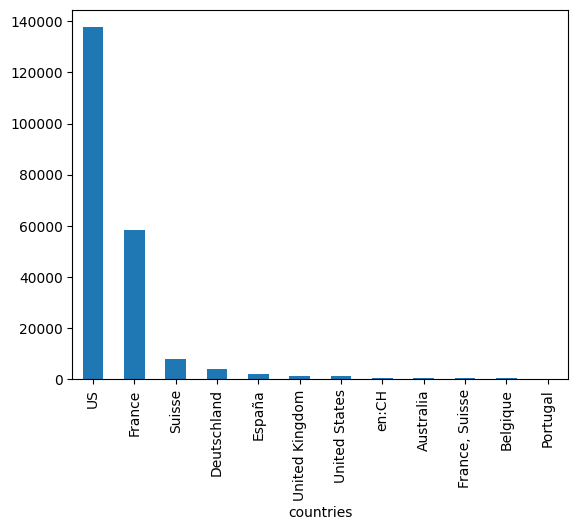

In [31]:
countries_info['rows_with_nutriscore_count']\
.sort_values(ascending=False)\
.head(12)\
.plot(kind='bar')

In [32]:
#top_fr = countries_fr_count.head(3).index.to_list()
#top_fr

In [33]:
#df.loc[df['countries'].isin(top_fr)].shape

In [34]:
df.loc[df['countries'] == 'France'].shape[0] / df.shape[0]

0.24095619318394373

In [35]:
df.loc[df['countries'] == 'France'].loc[df['nutrition-score-fr_100g'].notna()].shape[0] / df.shape[0]

0.1821355978701383

In [36]:
df.loc[df['countries'] == 'España'].loc[df['nutrition-score-fr_100g'].notna()]

,code,url,creator,created_datetime,last_modified_datetime,product_name,generic_name,quantity,packaging,packaging_tags,brands,brands_tags,categories,categories_tags,categories_fr,origins,origins_tags,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_fr,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_fr,ingredients_text,allergens,allergens_fr,traces,traces_tags,traces_fr,serving_size,no_nutriments,additives_n,additives,additives_tags,additives_fr,ingredients_from_palm_oil_n,ingredients_from_palm_oil,ingredients_from_palm_oil_tags,ingredients_that_may_be_from_palm_oil_n,ingredients_that_may_be_from_palm_oil,ingredients_that_may_be_from_palm_oil_tags,nutrition_grade_uk,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,states,states_tags,states_fr,main_category,main_category_fr,image_url,image_small_url,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,monounsaturated-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,omega-6-fat_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,omega-9-fat_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,sucrose_100g,glucose_100g,fructose_100g,lactose_100g,maltose_100g,maltodextrins_100g,starch_100g,polyols_100g,fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,ph_100g,fruits-vegetables-nuts_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
51837,0041570112717,http://world-fr.openfoodfacts.org/produit/0041570112717/leche-de-almendras-original-almond-breeze,javichu,2016-01-24T22:52:27Z,2016-01-24T23:19:56Z,Leche de almendras Original,Leche de almendras con calcio,1 l,"Tetra Brik,Ultrapasteurizado","tetra-brik,ultrapasteurizado","Almond Breeze,Blue Diamond Almonds,//Propiedad de://,Blue Diamond Growers Corporation","almond-breeze,blue-diamond-almonds,propiedad-de,blue-diamond-growers-corporation","Alimentos y bebidas de origen vegetal,Bebidas,Alimentos de origen vegetal,Lácteos,Frutos de cáscara y derivados,Bebidas de origen vegetal,Leches,Leches vegetales,Leches de almendras,Non-sugared beverages,Leches de frutos de cáscara","en:plant-based-foods-and-beverages,en:beverages,en:plant-based-foods,en:dairies,en:plant-based-beverages,en:milk-substitute,en:milks,en:nuts-and-their-products,en:plant-milks,en:nut-milks,en:almond-milks,en:non-sugared-beverages","Aliments et boissons à base de végétaux,Boissons,Aliments d'origine végétale,Produits laitiers,Boissons à base de végétaux,Substitut du lait,Laits,Fruits à coques et dérivés,Laits végétaux,Laits de fruits à coques,Laits d'amande,Boissons non sucrées","[ALMENDRAS],California,Estados Unidos","almendras,california,estados-unidos","Agrón (parroquia),Ames,La Coruña (provincia),Galicia,España","agron-parroquia,ames,la-coruna-provincia,galicia,espana","Vegetariano,FSC,Vegano,Sin gluten,Si

In [37]:
df = df.loc[df['countries'] == 'France'].loc[df['nutrition-score-fr_100g'].notna()]

In [38]:
df.shape

(58424, 160)

## Rows with nutriscore

In [39]:
# keep only rows with nutriscore

#df = df.loc[df['nutriscore_score'].notna()]

In [40]:
#df.filter(like='score', axis=1).columns

In [41]:
#df = df.loc[df['nutrition-score-fr_100g'].notna()]

In [42]:
#df.columns.values

## Categories : replace 'unknown' by nans

In [43]:
df[['pnns_groups_1', 'pnns_groups_2']].isna().sum()

pnns_groups_1    13824
pnns_groups_2    13733
dtype: int64

In [44]:
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'unknown'].count()

6843

In [45]:
df['pnns_groups_1'].loc[df['pnns_groups_2'] == 'unknown'].count()

6843

In [46]:
#print(df.apply(lambda col: col.unique()))

In [47]:
df['pnns_groups_1'].nunique()

13

In [48]:
df['pnns_groups_2'].nunique()

40

In [49]:
df['main_category_fr'].nunique()

909

In [50]:
df['pnns_groups_1'].head(50)

190                        NaN
191                        NaN
226                  Beverages
234                        NaN
240                  Beverages
242              Sugary snacks
279              Sugary snacks
283              Sugary snacks
299              Sugary snacks
301              Sugary snacks
307                        NaN
428              Sugary snacks
493                    unknown
495                        NaN
508              Sugary snacks
509                    unknown
523                        NaN
552                        NaN
564      Fruits and vegetables
632                        NaN
664                  Beverages
789                    unknown
1571                       NaN
6757                       NaN
7386                       NaN
9744             Sugary snacks
9890             Sugary snacks
11082                      NaN
11179                      NaN
11239                      NaN
11244                      NaN
11272            Sugary snacks
11276   

In [51]:
df['pnns_groups_1'].unique()

array([nan, 'Beverages', 'Sugary snacks', 'unknown',
       'Fruits and vegetables', 'Salty snacks', 'Composite foods',
       'Fat and sauces', 'Cereals and potatoes', 'fruits-and-vegetables',
       'Milk and dairy products', 'Fish Meat Eggs', 'sugary-snacks',
       'cereals-and-potatoes'], dtype=object)

In [52]:
df.shape

(58424, 160)

In [53]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
unknown                    6843
Sugary snacks              6779
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4745
Fish Meat Eggs             4528
Beverages                  4131
Fat and sauces             2688
Fruits and vegetables      2631
Salty snacks               1709
fruits-and-vegetables       415
sugary-snacks               358
cereals-and-potatoes          1
Name: count, dtype: int64

In [54]:
df['pnns_groups_2'].value_counts()

pnns_groups_2
unknown                             6843
One-dish meals                      3939
Biscuits and cakes                  3021
Cereals                             2378
Sweets                              2181
Processed meat                      2128
Cheese                              2097
Dressings and sauces                1812
Milk and yogurt                     1664
Chocolate products                  1577
Fish and seafood                    1511
Appetizers                          1343
Fruit juices                        1259
Sweetened beverages                 1253
Non-sugared beverages               1207
Vegetables                          1106
Bread                               1029
Fruits                               904
Breakfast cereals                    887
Fats                                 876
Meat                                 789
Dairy desserts                       638
Sandwich                             585
Ice cream                            464
Le

In [55]:
df[['pnns_groups_1', 'pnns_groups_2']] = df[['pnns_groups_1', 'pnns_groups_2']].replace('unknown', np.nan)

In [56]:
df['pnns_groups_1'].value_counts()

pnns_groups_1
Sugary snacks              6779
Composite foods            4909
Milk and dairy products    4863
Cereals and potatoes       4745
Fish Meat Eggs             4528
Beverages                  4131
Fat and sauces             2688
Fruits and vegetables      2631
Salty snacks               1709
fruits-and-vegetables       415
sugary-snacks               358
cereals-and-potatoes          1
Name: count, dtype: int64

In [57]:
df['pnns_groups_1'].loc[df['pnns_groups_1'] == 'unknown'].count()

0

In [58]:
df['pnns_groups_1'].loc[df['pnns_groups_2'] == 'unknown'].count()

0

In [59]:
df[['pnns_groups_1', 'pnns_groups_2']].isna().sum()

pnns_groups_1    20667
pnns_groups_2    20576
dtype: int64

In [60]:
df['pnns_groups_1'].value_counts().index.to_list()

['Sugary snacks',
 'Composite foods',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs',
 'Beverages',
 'Fat and sauces',
 'Fruits and vegetables',
 'Salty snacks',
 'fruits-and-vegetables',
 'sugary-snacks',
 'cereals-and-potatoes']

<Axes: xlabel='pnns_groups_1', ylabel='Count'>

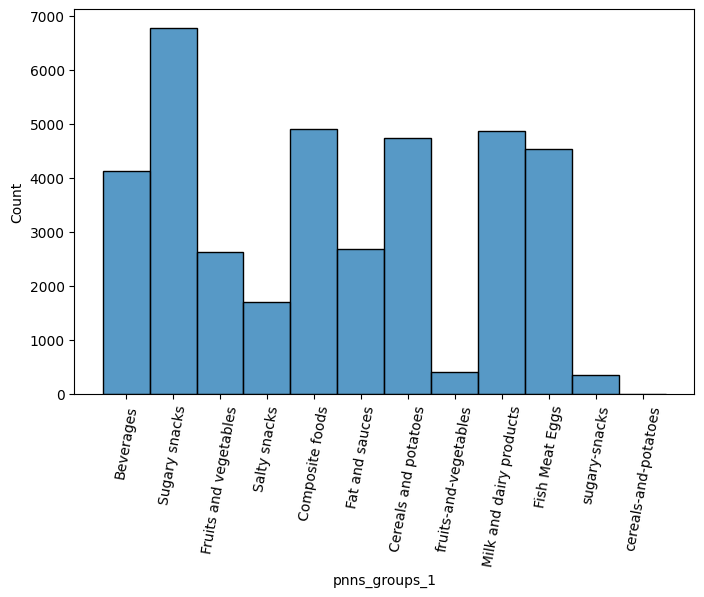

In [61]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
sns.histplot(data=df 
             ,x="pnns_groups_1"
            # , order = df['pnns_groups_1'].value_counts().index.to_list()
            )

<Axes: xlabel='pnns_groups_2', ylabel='Count'>

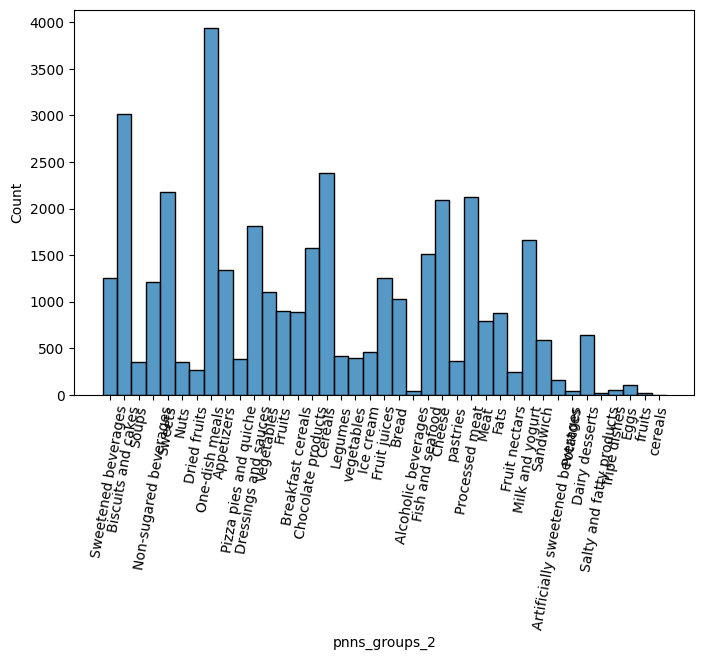

In [62]:
plt.figure(figsize=(8, 5))
plt.xticks(rotation=80)
sns.histplot(data=df, x="pnns_groups_2")

In [63]:
df.shape

(58424, 160)

## Mostly empty columns > removal

In [64]:
nan_values = df.isnull().sum()
nan_percent = nan_values /df.shape[0]*100
#nan_values.sort_values(ascending=True)

In [65]:
nan_info = pd.concat([nan_values,nan_percent],axis=1)
nan_info.columns = ['count', 'null_percent']

nan_info = nan_info.sort_values(by='null_percent',ascending=True)
nan_info

,count,null_percent
code,0,0.000000
states_fr,0,0.000000
states_tags,0,0.000000
states,0,0.000000
nutrition_grade_fr,0,0.000000
countries_fr,0,0.000000
countries_tags,0,0.000000
countries,0,0.000000
nutrition-score-uk_100g,0,0.000000
nutrition-score-fr_100g,0,0.000000


In [66]:
# find columns with -40% missing values

df_fill_mask = nan_info.loc[nan_info["null_percent"] <= 40.0]
mask_columns = df_fill_mask.index

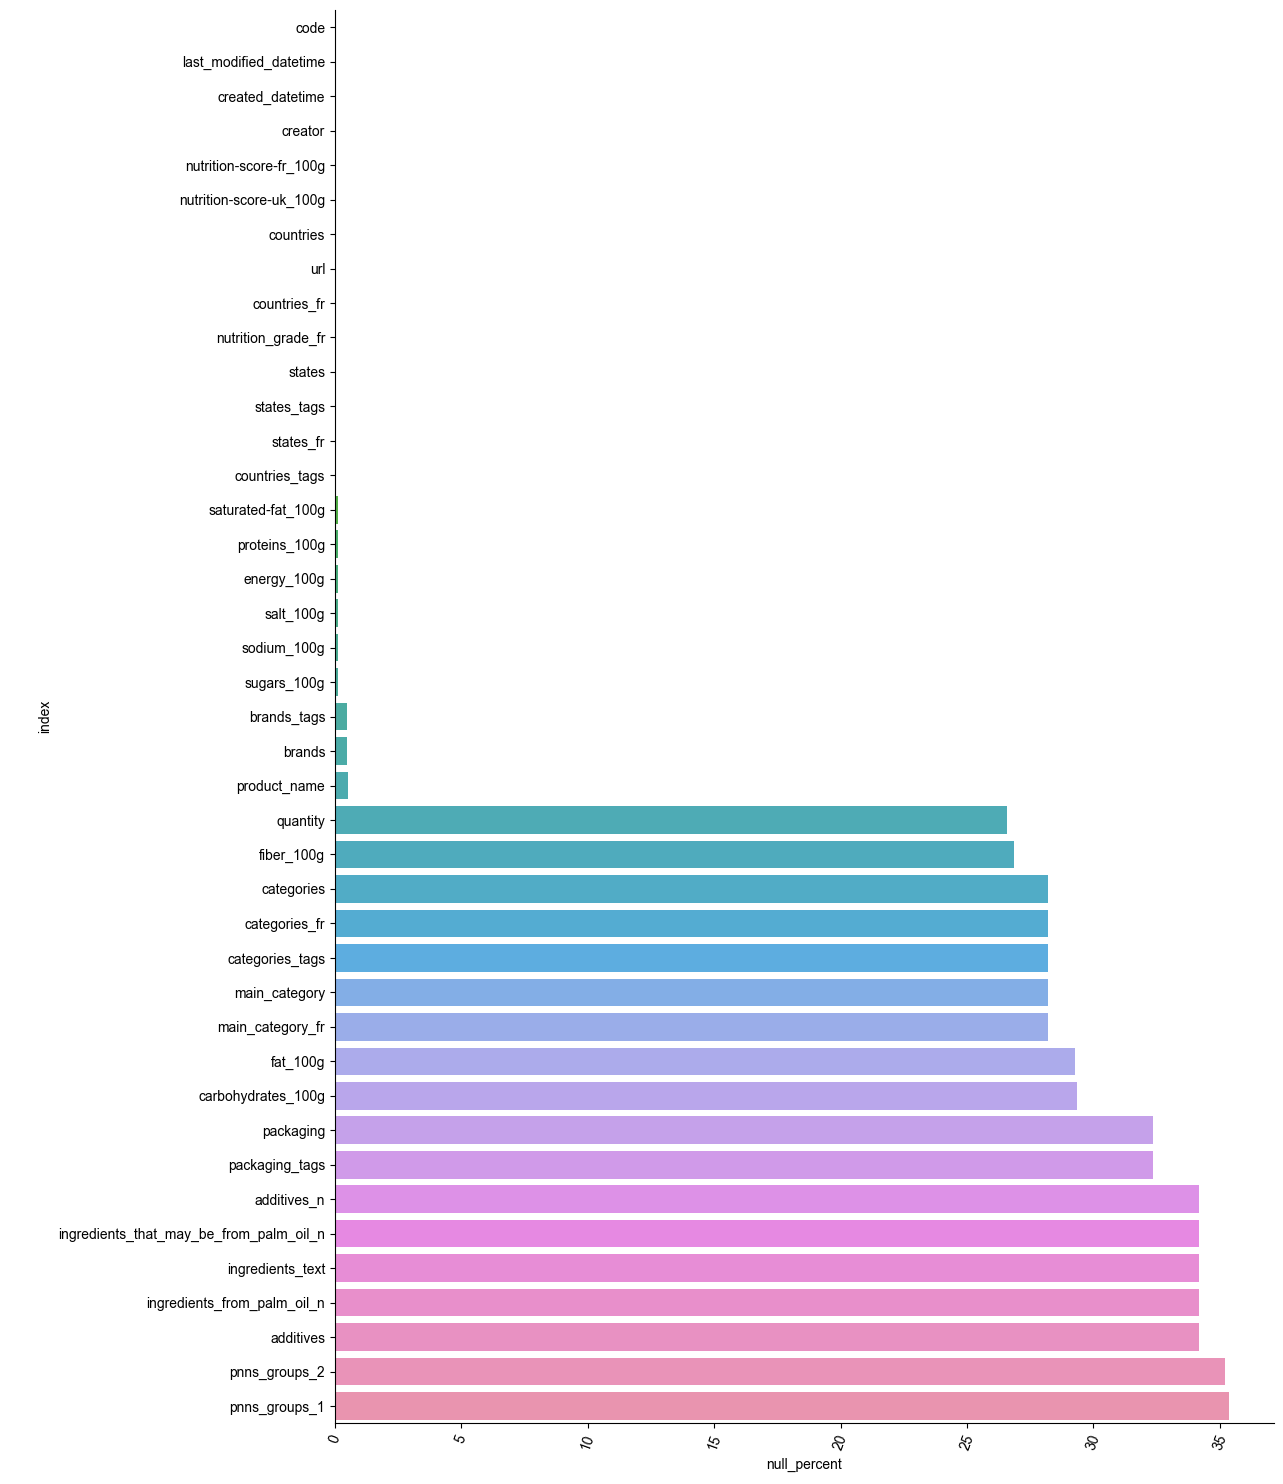

In [67]:
#df_fill_mask
plot_df_xy(df_fill_mask.reset_index().sort_values(by='null_percent',ascending=True), 'null_percent','index', 15)

In [68]:
df[mask_columns].head()

,code,states_fr,states_tags,states,nutrition_grade_fr,countries_fr,countries_tags,countries,nutrition-score-uk_100g,nutrition-score-fr_100g,url,creator,created_datetime,last_modified_datetime,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,brands,brands_tags,product_name,quantity,fiber_100g,categories,categories_fr,categories_tags,main_category,main_category_fr,fat_100g,carbohydrates_100g,packaging,packaging_tags,additives_n,ingredients_that_may_be_from_palm_oil_n,ingredients_text,ingredients_from_palm_oil_n,additives,pnns_groups_2,pnns_groups_1
190,0000010187319,"A compléter,Informations nutritionnelles complétées,Ingrédients à compléter,Date limite à compléter,en:Packaging-code-to-be-completed,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité à compléter,Nom du produit complete,Photos à valider,Photos envoyées","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:packaging-code-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-to-be-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","en:to-be-completed, en:nutrition-facts-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-to-be-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded",d,France,en:france,France,14.0,14.0,http://world-fr.openfoodfacts.org/produit/0000010187319/mini-confettis-alice-delice,kiliweb,2017-02-17T10:05:54Z,2017-02-17T10:05:54Z,0.6,1753.0,0.0100,0.003937,87.7,0.8,Alice Délice,alice-delice,Mini Confettis,NaN,0.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,0000010207260,"A compléter,Informations nutritionnelles complétées,Ingrédients à compléter,Date limite à compléter,en:Packaging-code-to-be-completed,Caractéristiques à compléter,Catégories à compléter,Marques complétées,Emballage à compléter,Quantité à compléter,Nom du produit complete,Photos à valider,Photos envoyées","en:to-be-completed,en:nutrition-facts-completed,en:ingredients-to-be-completed,en:expiration-date-to-be-completed,en:packaging-code-to-be-completed,en:characteristics-to-be-completed,en:categories-to-be-completed,en:brands-completed,en:packaging-to-be-completed,en:quantity-to-be-completed,en:product-name-completed,en:photos-to-be-validated,en:photos-uploaded","en:to-be-completed, en:nutrition-facts-completed, en:ingredients-to-be-completed, en:expiration-date-to-be-completed, en:packaging-code-to-be-completed, en:characteristics-to-be-completed, en:categories-to-be-completed, en:brands-completed, en:packaging-to-be-completed, en:quantity-to-be-completed, en:product-name-completed, en:photos-to-be-validated, en:photos-uploaded",d,France,en:france,France,14.0,14.0,http://world-fr.openfoodfacts.org/produit/0000010207260/praline-amande-et-noisette-alice-delice,kiliweb,2017-03-22T17:17:11Z,2017-03-22T17:29:17Z,9.5,2406.0,0.0030,0.001181,50.3,2.9,Alice Délice,alice-delice,Praliné Amande Et Noisette,NaN,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
226,0000040608754,"A vérifier,Complet,Informations nutritionnelles complétées,Ingrédients complétés,Date limite à compléter,Caractéristiques complétées,Catégories complétées,Marques complétées,Emballage complété,Quantité complétée,Nom du produit complete,Photos validées,Photos envoyées","en:to-be-checked,en:complete,en:nutrition-facts-completed,en:ingredients-completed,en:expiration-date-to-be-completed,en:characteristics-completed,en:categories-completed,en:brands-completed,en:packaging-completed,en:quantity-completed,en:product-name-completed,en:photos-validated,en:photos-uploaded","en:to-be-checked, en:complete, en:nut

In [69]:
df[mask_columns].columns.to_list()

['code',
 'states_fr',
 'states_tags',
 'states',
 'nutrition_grade_fr',
 'countries_fr',
 'countries_tags',
 'countries',
 'nutrition-score-uk_100g',
 'nutrition-score-fr_100g',
 'url',
 'creator',
 'created_datetime',
 'last_modified_datetime',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'brands',
 'brands_tags',
 'product_name',
 'quantity',
 'fiber_100g',
 'categories',
 'categories_fr',
 'categories_tags',
 'main_category',
 'main_category_fr',
 'fat_100g',
 'carbohydrates_100g',
 'packaging',
 'packaging_tags',
 'additives_n',
 'ingredients_that_may_be_from_palm_oil_n',
 'ingredients_text',
 'ingredients_from_palm_oil_n',
 'additives',
 'pnns_groups_2',
 'pnns_groups_1']

In [70]:
columns_to_keep = [
 'code',
# 'states_fr',
# 'states_tags',
# 'states',
 'nutrition_grade_fr',
# 'countries_fr',
# 'countries_tags',
# 'countries',
# 'nutrition-score-uk_100g',
 'nutrition-score-fr_100g',
# 'url',
# 'creator',
# 'created_datetime',
# 'last_modified_datetime',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
# 'brands',
# 'brands_tags',
 'product_name',
# 'quantity',
 'fiber_100g',
# 'categories',
# 'categories_fr',
# 'categories_tags',
# 'main_category',
# 'main_category_fr',
 'fat_100g',
 'carbohydrates_100g',
# 'packaging',
# 'packaging_tags',
# 'additives_n',
# 'ingredients_that_may_be_from_palm_oil_n',
# 'ingredients_text',
# 'ingredients_from_palm_oil_n',
# 'additives',
 'pnns_groups_2',
 'pnns_groups_1'
]

In [71]:
sm_df = df.loc[:,columns_to_keep]

In [72]:
df.shape

(58424, 160)

In [73]:
sm_df.shape

(58424, 15)

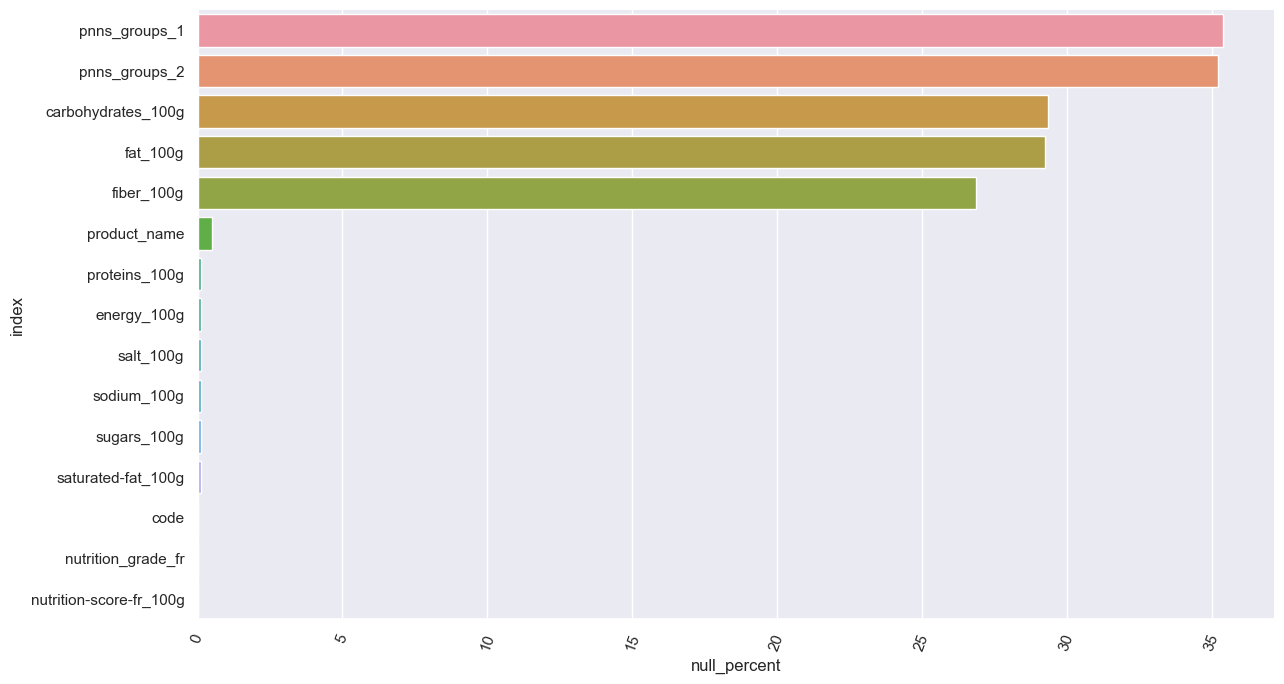

In [74]:
top_sm_df = get_df_columns_na(sm_df).sort_values(by='null_percent',ascending=False)
plot_df_xy(top_sm_df.reset_index(), 'null_percent', 'index', 7)

In [75]:
top_sm_df

,count,null_percent
pnns_groups_1,20667,35.374161
pnns_groups_2,20576,35.218403
carbohydrates_100g,17142,29.340682
fat_100g,17091,29.253389
fiber_100g,15690,26.855402
product_name,297,0.508353
proteins_100g,72,0.123237
energy_100g,72,0.123237
salt_100g,72,0.123237
sodium_100g,72,0.123237


In [76]:
sm_df.head(50)

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
190,0000010187319,d,14.0,0.6,1753.0,0.01000,0.003937,87.7,0.8,Mini Confettis,0.9,NaN,NaN,NaN,NaN
191,0000010207260,d,14.0,9.5,2406.0,0.00300,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
226,0000040608754,e,13.0,0.0,177.0,0.02540,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.00,10.40,Sweetened beverages,Beverages
234,0000069161025,d,15.0,7.5,1079.0,0.80000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
240,0000087177756,e,13.0,0.0,177.0,0.10000,0.039370,10.4,0.0,7Up,NaN,0.00,10.40,Sweetened beverages,Beverages
242,000010,d,12.0,6.0,1900.0,0.66000,0.259843,26.0,2.5,Madeleines nature,1.5,23.00,55.00,Biscuits and cakes,Sugary snacks
279,000030,d,13.0,5.8,1768.0,0.65000,0.255906,28.0,2.5,Cakes Raisins,1.8,19.00,56.00,Biscuits and cakes,Sugary snacks
283,000031,d,12.0,4.9,1670.0,0.60000,0.236220,34.0,2.0,Cakes aux Fruits,1.5,15.00,60.00,Biscuits and cakes,Sugary snacks
299,000050,e,22.0,8.0,1868.0,0.55000,0.216535,39.0,10.0,Financiers aux Amandes,1.7,23.00,51.00,Biscuits and cakes,Sugary snacks
301,000051,e,22.0,8.1,1896.0,0.78000,0.307087,37.0,10.0,Fondants Citron,2.5,24.00,50.00,Biscuits and cakes,Sugary snacks


# Id & replacing wrong values

##  Impossible values (negative / over maximum)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17142     29.340682
fat_100g                 17091     29.253389
fiber_100g               15690     26.855402
nutrition-score-fr_100g   9845     16.850952
product_name               297      0.508353
sugars_100g                 73      0.124949
proteins_100g               72      0.123237
energy_100g                 72      0.123237
salt_100g                   72      0.123237
sodium_100g                 72      0.123237
saturated-fat_100g          72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


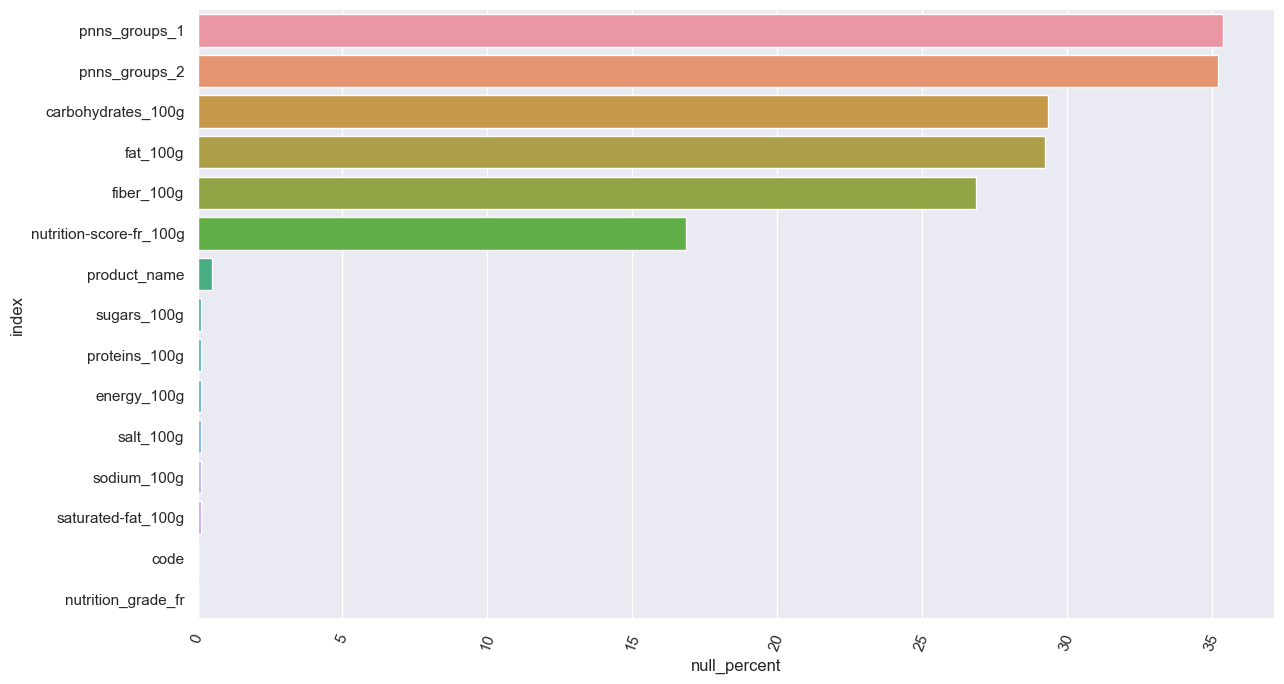

In [94]:
show_nulls(sm_df, verbose=True)

In [91]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,48579.000000,58352.000000,5.835200e+04,58352.000000,58352.000000,58351.000000,58352.000000,42734.000000,41333.000000,41282.000000
mean,11.084419,7.774643,1.177408e+03,1.086048,0.427578,13.198267,5.398200,2.505745,13.265636,27.306794
std,7.752168,7.882460,1.350234e+04,3.827492,1.506836,18.974829,8.560182,4.615174,16.824987,27.162540
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.800000,4.330000e+02,0.080000,0.031496,1.000000,0.300000,0.000000,1.400000,4.000000
50%,11.000000,6.000000,1.033000e+03,0.570000,0.224409,4.000000,1.900000,1.300000,6.900000,14.000000
75%,17.000000,11.000000,1.648000e+03,1.250000,0.492126,17.000000,7.300000,3.100000,21.000000,52.500000
max,40.000000,100.000000,3.251373e+06,211.000000,83.000000,104.000000,210.000000,178.000000,380.000000,190.000000


In [92]:
sm_df.dtypes

code                        object
nutrition_grade_fr          object
nutrition-score-fr_100g    float64
proteins_100g              float64
energy_100g                float64
salt_100g                  float64
sodium_100g                float64
sugars_100g                float64
saturated-fat_100g         float64
product_name                object
fiber_100g                 float64
fat_100g                   float64
carbohydrates_100g         float64
pnns_groups_2               object
pnns_groups_1               object
dtype: object

In [80]:
sm_df.columns

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [81]:
sm_num_cols = [ 'proteins_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g']
energy_cols = [ 'energy_100g']
scores_cols = [ 'nutrition_grade_fr', 'nutrition-score-fr_100g', 
               #'ecoscore_grade'
              ]

In [83]:
# checking columns with negative values
for x in ['nutrition-score-fr_100g', 'sugars_100g']:
    print(sm_df[x].loc[sm_df[x] < 0])

789      -3.0
12896    -2.0
12897    -1.0
12967    -2.0
14314    -5.0
         ... 
320326   -2.0
320494   -5.0
320497   -1.0
320524   -4.0
320751   -4.0
Name: nutrition-score-fr_100g, Length: 9845, dtype: float64
195761   -0.1
Name: sugars_100g, dtype: float64


In [84]:
# handling columns with negative values
for x in ['nutrition-score-fr_100g', 'sugars_100g']:
    sm_df[x].loc[sm_df[x] < 0] = np.nan

In [95]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17142     29.340682
fat_100g                 17091     29.253389
fiber_100g               15690     26.855402
nutrition-score-fr_100g   9845     16.850952
product_name               297      0.508353
sugars_100g                 73      0.124949
proteins_100g               72      0.123237
energy_100g                 72      0.123237
salt_100g                   72      0.123237
sodium_100g                 72      0.123237
saturated-fat_100g          72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [100]:
# handling columns with over max (100) values
for x in sm_num_cols : 
    sm_df[x].loc[sm_df[x] > 100] = np.nan

In [101]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17148     29.350952
fat_100g                 17093     29.256812
fiber_100g               15691     26.857114
nutrition-score-fr_100g   9845     16.850952
product_name               297      0.508353
sugars_100g                 76      0.130084
salt_100g                   74      0.126660
saturated-fat_100g          73      0.124949
proteins_100g               72      0.123237
energy_100g                 72      0.123237
sodium_100g                 72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [102]:
for x in energy_cols : 
    print(sm_df[x].loc[sm_df[x] >= 900])

190       1753.0
191       2406.0
234       1079.0
242       1900.0
279       1768.0
           ...  
320698    1996.0
320702    1031.0
320740    1084.0
320751    1643.0
320757    2406.0
Name: energy_100g, Length: 31993, dtype: float64


In [103]:
# fields info : https://static.openfoodfacts.org/data/data-fields.txt
# https://fr.openfoodfacts.org/guide-pour-les-producteurs
# energy_100g =  kJ / 100g

# max cal = fat
# fat max cal = 9 kCal per gram of fat
# 100g of fat = 900 kCal

# 1 kCal = 4.184 kJ (kJoul)
# 100g of fat = 900 x 4.184 = 3765 kJoul

for x in energy_cols : 
    sm_df[x].loc[sm_df[x] >= 3765] = np.nan

In [104]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            20667     35.374161
pnns_groups_2            20576     35.218403
carbohydrates_100g       17148     29.350952
fat_100g                 17093     29.256812
fiber_100g               15691     26.857114
nutrition-score-fr_100g   9845     16.850952
energy_100g                299      0.511776
product_name               297      0.508353
sugars_100g                 76      0.130084
salt_100g                   74      0.126660
saturated-fat_100g          73      0.124949
proteins_100g               72      0.123237
sodium_100g                 72      0.123237
code                         0      0.000000
nutrition_grade_fr           0      0.000000


In [105]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,48579.000000,58352.000000,58125.000000,58350.000000,58352.000000,58348.000000,58351.000000,42733.000000,41331.000000,41276.000000
mean,11.084419,7.774643,1104.753333,1.080327,0.427578,13.193662,5.394693,2.501638,13.254544,27.292755
std,7.752168,7.882460,760.445320,3.692131,1.506836,18.964441,8.518247,4.536472,16.722320,27.136747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,1.800000,431.000000,0.080000,0.031496,1.000000,0.300000,0.000000,1.400000,4.000000
50%,11.000000,6.000000,1029.000000,0.570000,0.224409,4.000000,1.900000,1.300000,6.900000,14.000000
75%,17.000000,11.000000,1642.000000,1.250000,0.492126,17.000000,7.300000,3.100000,21.000000,52.500000
max,40.000000,100.000000,3761.000000,100.000000,83.000000,100.000000,100.000000,100.000000,100.000000,100.000000


[Text(0, 0, 'proteins_100g'),
 Text(1, 0, 'salt_100g'),
 Text(2, 0, 'sodium_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'saturated-fat_100g'),
 Text(5, 0, 'fiber_100g'),
 Text(6, 0, 'fat_100g'),
 Text(7, 0, 'carbohydrates_100g')]

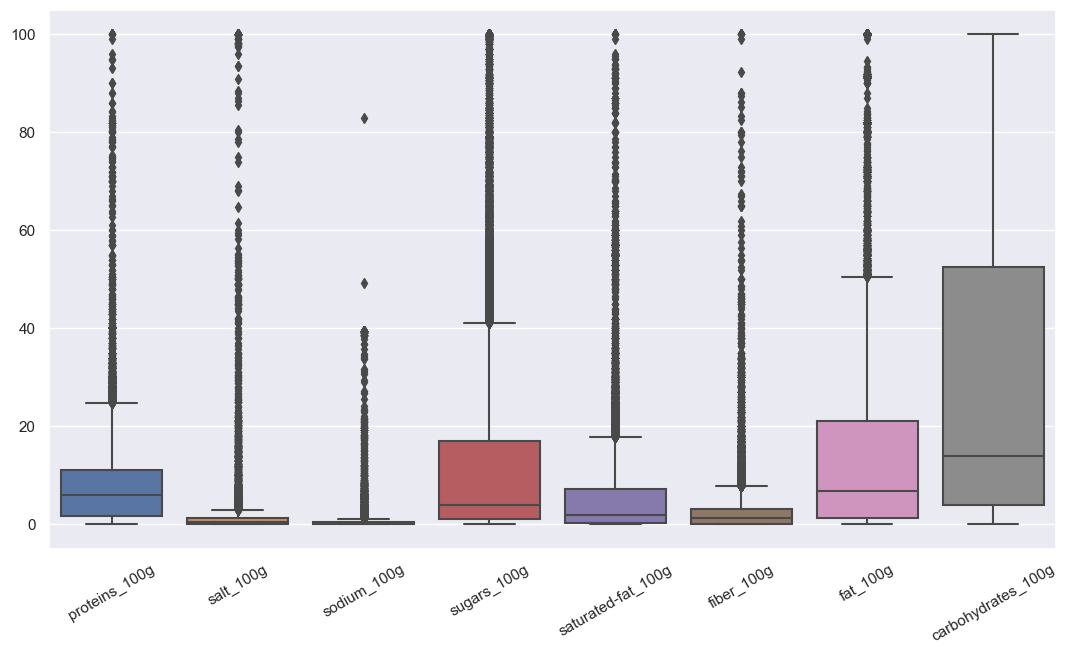

In [106]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

In [100]:
#plt.figure(figsize=(8, 5))
#boxplot = sm_df.boxplot(column=sm_num_cols)
#plt.xticks(rotation=80)

[Text(0, 0, 'energy_100g')]

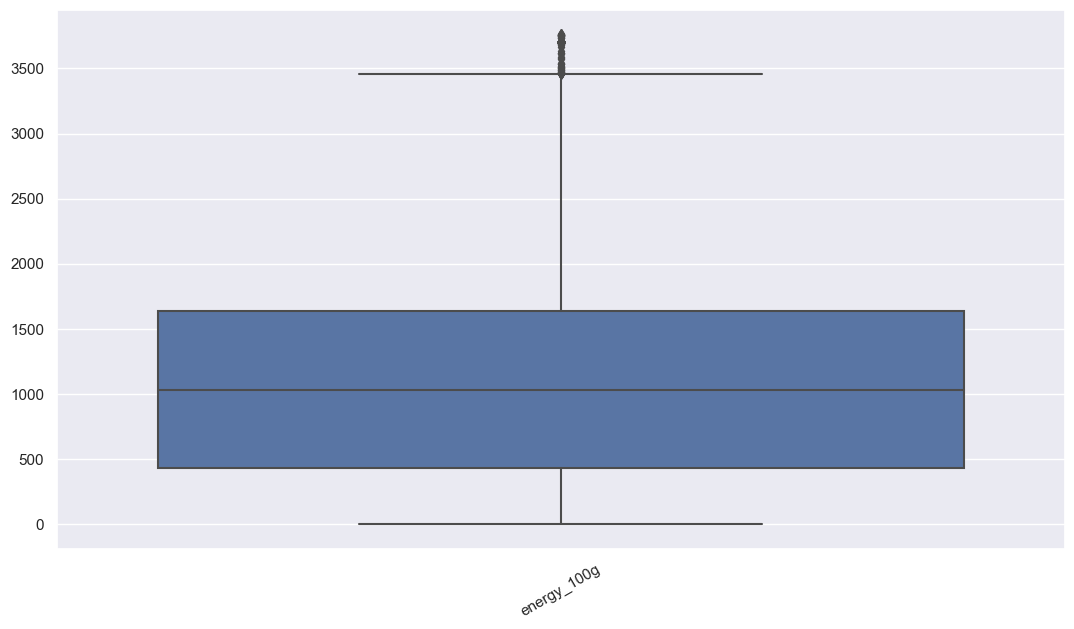

In [107]:
#boxplot = sm_df.boxplot(column=energy_cols)
ax = sns.boxplot(data=sm_df[energy_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'nutrition-score-fr_100g')]

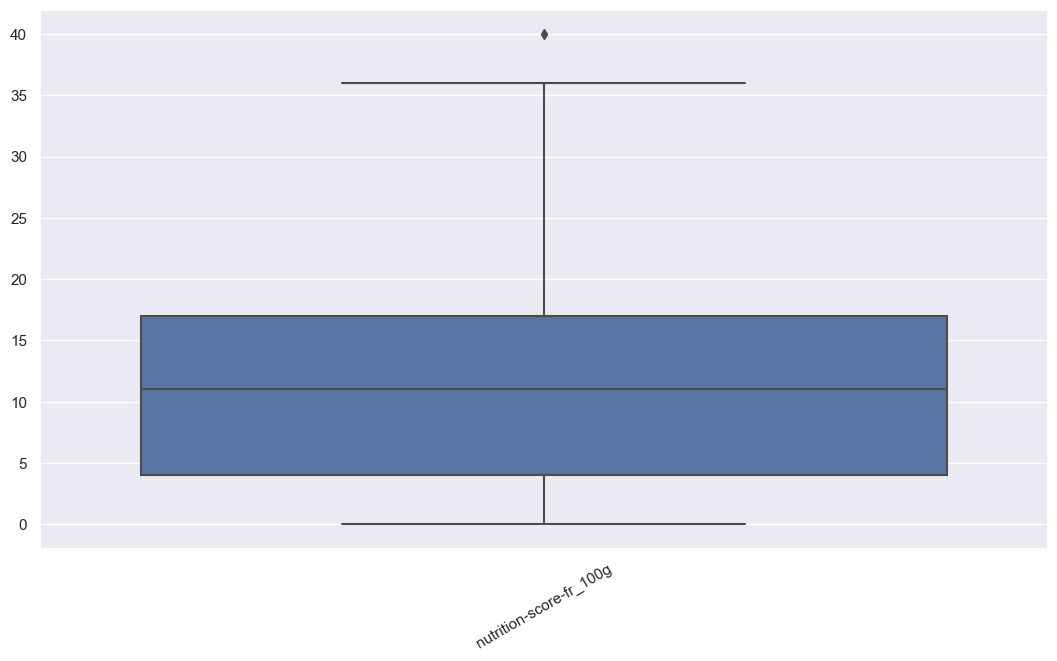

In [112]:
ax = sns.boxplot(data=sm_df[scores_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

#### Checking sum of "per 100g" components

In [103]:
#sm_df['pnns_groups_1'].value_counts()

In [108]:
sm_df[sm_num_cols].head()

,proteins_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
190,0.6,0.0100,0.003937,87.7,0.8,0.9,NaN,NaN
191,9.5,0.0030,0.001181,50.3,2.9,3.9,NaN,NaN
226,0.0,0.0254,0.010000,10.4,0.0,0.0,0.0,10.4
234,7.5,0.8000,0.314961,1.0,11.0,1.4,NaN,NaN
240,0.0,0.1000,0.039370,10.4,0.0,NaN,0.0,10.4


In [109]:
sm_df['comp_sum'] = sm_df[sm_num_cols].sum(axis=1)
sm_df['comp_sum'].head()

190    90.013937
191    66.604181
226    20.835400
234    22.014961
240    20.939370
Name: comp_sum, dtype: float64

In [110]:
comp_sum_100p = sm_df['comp_sum'][sm_df['comp_sum'] > 100]
comp_sum_100p.count()

11419

In [118]:
comp_sum_100p.sort_values(ascending = False)

283105    402.787402
225939    397.795276
225022    390.165354
246934    296.968504
285429    279.685039
             ...    
242410    100.009055
209376    100.008920
204444    100.008661
251691    100.008661
209997    100.007638
Name: comp_sum, Length: 11419, dtype: float64

In [114]:
comp_sum_100p.values

array([114.91984252, 114.00590551, 118.23622047, ..., 131.        ,
       162.48362205, 100.64771654])

<Axes: >

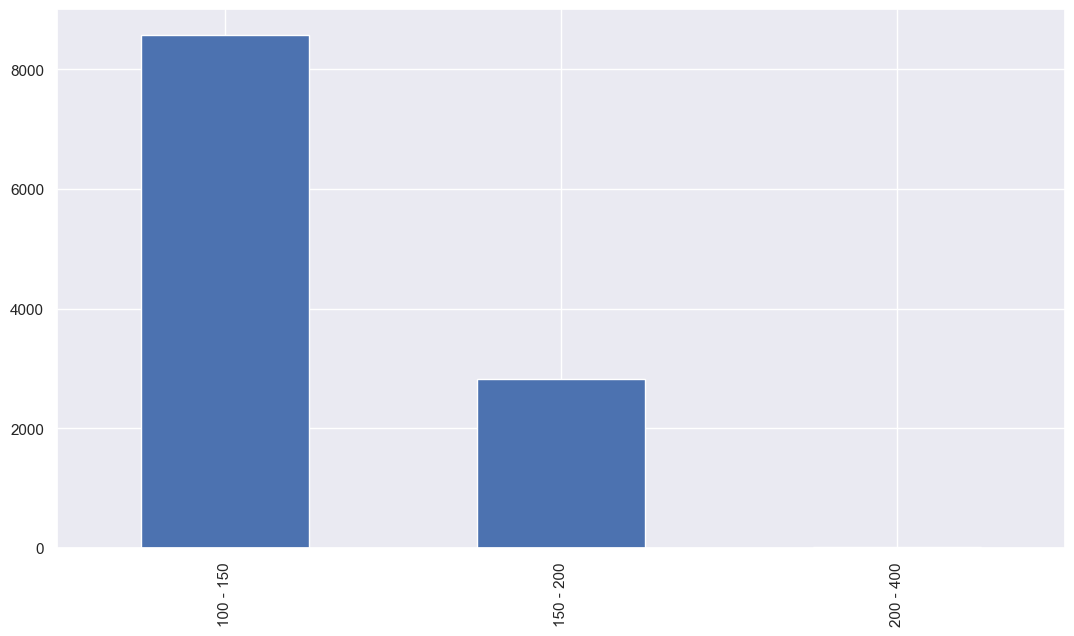

In [142]:
out = pd.cut(comp_sum_100p.values 
             , [100, 150, 200, 400]
             , labels=['100 - 150', '150 - 200', '200 - 400']
            )
out.value_counts().sort_index().plot.bar()

In [148]:
sm_df = sm_df[sm_df['comp_sum'] <= 100]
sm_df.drop('comp_sum', axis = 1, inplace=True)

In [151]:
#sm_df[['pnns_groups_1', 'pnns_groups_2']].fillna('unknown', inplace=True)
#sm_df['pnns_groups_1'].fillna('unknown', inplace=True)

In [152]:
sm_df.describe()

,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,37416.000000,46933.000000,46760.000000,46932.000000,46933.000000,46929.000000,46932.000000,34988.000000,30058.000000,30012.000000
mean,9.368452,8.005150,902.029142,1.032709,0.407618,8.366499,4.259650,2.074272,9.417039,16.343275
std,7.272513,8.164768,665.180770,2.221951,0.903318,14.124037,7.050932,4.090862,12.629693,20.106831
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.530000,347.000000,0.080000,0.031496,0.800000,0.200000,0.000000,1.000000,2.500000
50%,9.000000,5.800000,753.000000,0.650000,0.255906,2.900000,1.400000,1.000000,4.200000,9.500000
75%,15.000000,12.000000,1400.000000,1.300000,0.511811,10.000000,5.000000,2.600000,12.900000,20.500000
max,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [153]:
#to_remove check
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18791     39.976598
pnns_groups_2            18700     39.783002
carbohydrates_100g       16993     36.151473
fat_100g                 16947     36.053611
fiber_100g               12017     25.565365
nutrition-score-fr_100g   9589     20.399957
energy_100g                245      0.521221
product_name               209      0.444634
sugars_100g                 76      0.161685
salt_100g                   73      0.155303
saturated-fat_100g          73      0.155303
proteins_100g               72      0.153175
sodium_100g                 72      0.153175
code                         0      0.000000
nutrition_grade_fr           0      0.000000


### Product names

In [155]:
#drop lines missing product names

In [156]:
sm_df.dropna(axis=0, subset = ['product_name'], inplace = True)

In [157]:
df_prod_ct = sm_df['product_name'].value_counts(dropna=False)
df_prod_ct_pct = sm_df['product_name'].value_counts(dropna=False, normalize=True)

In [158]:
df_prod_ct.head(20)

product_name
Mayonnaise                           41
Orange                               35
Moutarde de Dijon                    33
Haricots rouges                      32
Mayonnaise à la moutarde de Dijon    32
Mozzarella                           30
Tomato Ketchup                       30
Lait demi-écrémé                     29
Coquillettes                         29
Jus d'orange                         27
Spaghetti                            27
Macédoine de légumes                 26
Pois chiches                         26
Riz Basmati                          25
Lait de coco                         25
Ratatouille                          24
Emmental                             23
Olives vertes dénoyautées            22
Comté                                22
Ketchup                              21
Name: count, dtype: int64

In [160]:
df_prod_ct_pct.head(20)

product_name
Mayonnaise                           0.000876
Orange                               0.000748
Moutarde de Dijon                    0.000705
Haricots rouges                      0.000684
Mayonnaise à la moutarde de Dijon    0.000684
Mozzarella                           0.000641
Tomato Ketchup                       0.000641
Lait demi-écrémé                     0.000620
Coquillettes                         0.000620
Jus d'orange                         0.000577
Spaghetti                            0.000577
Macédoine de légumes                 0.000556
Pois chiches                         0.000556
Riz Basmati                          0.000534
Lait de coco                         0.000534
Ratatouille                          0.000513
Emmental                             0.000491
Olives vertes dénoyautées            0.000470
Comté                                0.000470
Ketchup                              0.000449
Name: proportion, dtype: float64

In [161]:
sm_df.isna().sum().sum()

93157

In [162]:
sm_df.shape

(46796, 15)

### Barcodes

In [118]:
# https://world.openfoodfacts.org/data/data-fields.txt
#code : barcode of the product (can be EAN-13 or internal codes for some food stores), 
#       for products without a barcode, Open Food Facts assigns a number starting with the 200 reserved prefix


In [163]:
sm_df.shape

(46796, 15)

In [164]:
# count code values
sm_df['code'].count()

46796

In [165]:
# count code values with 200 prefix
sm_df['code'].loc[sm_df['code'].str.startswith('200')].count()

542

In [166]:
sm_df = sm_df.loc[~sm_df['code'].str.startswith('200')]

In [167]:
sm_df.shape

(46254, 15)

### Categories duplicates

#### Main categories

In [168]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Composite foods            4763
Milk and dairy products    4725
Fish Meat Eggs             4444
Beverages                  3789
Cereals and potatoes       3464
Fruits and vegetables      2334
Fat and sauces             2007
Sugary snacks               983
Salty snacks                581
fruits-and-vegetables       407
sugary-snacks               248
cereals-and-potatoes          1
Name: count, dtype: int64

In [173]:
# check duplicate sugary-snacks
sm_df[sm_df['pnns_groups_1'] == 'sugary-snacks'].head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
178029,20116859,d,13.0,7.5,1418.0,1.140,0.448819,16.0,3.0,Brioche tressée pépites chocolat,NaN,9.6,55.0,pastries,sugary-snacks
178661,20208202,d,14.0,8.4,1513.0,1.000,0.393701,17.4,3.1,10 Pains au lait aux pépites de chocolat,NaN,12.5,52.1,pastries,sugary-snacks
179351,20342371,d,16.0,9.0,1449.0,1.270,0.500000,12.0,7.5,Petits pains au lait (x 12) Extra moelleux XXL,1.5,10.0,54.0,pastries,sugary-snacks
179517,20376390,d,13.0,10.0,1525.0,1.016,0.400000,13.0,5.4,Pains au lait (x 10) aux pépites de chocolat au lait,2.0,12.0,53.0,pastries,sugary-snacks
180027,20466473,d,11.0,8.0,1437.0,1.100,0.433071,12.0,1.5,10 Pains au Lait,NaN,10.5,52.8,pastries,sugary-snacks


In [170]:
# check duplicate cereals-and-potatoes
sm_df[sm_df['pnns_groups_1'] == 'cereals-and-potatoes']

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
218773,3270160046201,a,NaN,2.6,334.0,0.0,0.0,7.5,0.4,Maïs doux en épis,2.5,1.7,12.2,cereals,cereals-and-potatoes


In [174]:
# replace 'sugary-snacks' => 'Cereals and potatoes'
sm_df['pnns_groups_1'].loc[sm_df['pnns_groups_1'] == 'sugary-snacks'] = 'Sugary snacks'

# replace 'cereals-and-potatoes' => 'Cereals and potatoes'
sm_df['pnns_groups_1'].loc[sm_df['pnns_groups_1'] == 'cereals-and-potatoes'] = 'Cereals and potatoes'

In [175]:
sm_df['pnns_groups_1'].value_counts()

pnns_groups_1
Composite foods            4763
Milk and dairy products    4725
Fish Meat Eggs             4444
Beverages                  3789
Cereals and potatoes       3465
Fruits and vegetables      2334
Fat and sauces             2007
Sugary snacks              1231
Salty snacks                581
fruits-and-vegetables       407
Name: count, dtype: int64

#### Sub categories

In [128]:
#sm_df[sm_df['pnns_groups_2'] == 'pastries']

In [129]:
# replace 'sugary-snacks' => 'Sugary snacks'
#sm_df['pnns_groups_2'].loc[sm_df['pnns_groups_2'] == 'pastries'] = 'Pastries'

In [130]:
#sm_df['pnns_groups_2'].value_counts()

### beverages / alcoholic

In [153]:
sm_df['pnns_groups_1'].value_counts()

Fish Meat Eggs             12759
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1246
Alcoholic beverages            3
Name: pnns_groups_1, dtype: int64

In [154]:
sm_df[['product_name','pnns_groups_1']].loc[sm_df['pnns_groups_1'] == 'Alcoholic beverages']

,product_name,pnns_groups_1
1258348,Kombucha Jubiles Hibiscus Myrtille,Alcoholic beverages
1258364,Kombucha Pêche,Alcoholic beverages
1387724,Rothaus Radler Zäpfle ohne Zucker,Alcoholic beverages


In [157]:
#sm_df[['product_name','pnns_groups_1']].loc[sm_df['product_name'].str.lower() == 'kombucha']

In [142]:
## non-possible as masking wasn't doable with nan values

In [158]:
with pd.option_context("display.max_rows", 1000):
   display(sm_df[['product_name','pnns_groups_1']].loc[sm_df['product_name'].str.lower().str.contains('kombucha')])

,product_name,pnns_groups_1
393892,Original Kombucha,Beverages
419533,Kombucha,Beverages
420274,Kombucha Framboise Inspiration,Beverages
420279,Kombucha,Beverages
424928,Kombucha l'eau à la bouche,Beverages
424997,Kombucha pomme verte,Beverages
425001,Kombucha,Beverages
425002,Kombucha Fruits Rouges Gourmands,Beverages
432591,Kombucha,Beverages
432636,Kombucha fraise menthe,Beverages


In [ ]:
# the only 3 items listed are low in alcohol % (less than 2%) 
# and have a large quantity of equivalent articles all listed under "Beverages"
# => changing category 'Alcoholic beverages' into 'Beverages' to normalize

In [161]:
sm_df['pnns_groups_1'] = sm_df['pnns_groups_1'].replace('Alcoholic beverages', 'Beverages')

In [162]:
sm_df['pnns_groups_1'].value_counts()

Fish Meat Eggs             12759
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1249
Name: pnns_groups_1, dtype: int64

#### check nans

In [163]:
sm_df[sm_df['pnns_groups_1'].isna()]

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
887,0000146013124,Beignet chocolat,12.0,d,NaN,385.000000,18.000000,2.000000,47.000000,1.900000e+01,6.500000,0.710000,0.284000
918,0000181009847,4 Beignets parfum chocolat-noisette *4,13.0,d,NaN,394.000000,19.000000,2.100000,48.000000,1.900000e+01,6.700000,0.700000,0.280000
921,0000183013125,4 beignets à la pomme,11.0,d,NaN,310.000000,9.600000,1.500000,49.000000,2.000000e+01,6.600000,0.720000,0.288000
923,0000190014436,Beignets chocolats noisettes decongelé,13.0,d,NaN,394.000000,19.000000,2.100000,48.000000,1.900000e+01,6.700000,0.700000,0.280000
933,00002009,Mousse au chocolat noir,19.0,e,NaN,322.000000,19.800000,12.700000,25.000000,2.380000e+01,6.600000,0.190000,0.076000
1237,0000660000006,Spirulina 125GR Eco Salud Viva,0.0,b,NaN,378.000000,8.200000,1.100000,9.100000,3.000000e+00,63.500000,0.002816,0.001126
1416,0000792009847,4 beignets à la pomme,11.0,d,NaN,310.000000,9.600000,1.500000,49.000000,2.000000e+01,6.600000,0.720000,0.288000
1528,0000936013129,Beignets à l'abricot,11.0,d,NaN,314.000000,9.600000,1.400000,50.000000,2.000000e+01,6.700000,0.720000,0.288000
1859,000127613,Chia seeds,2.0,b,NaN,436.000000,31.000000,3.000000,2.000000,0.000000e+00,20.000000,0.000000,0.000000
2099,000155259,Informed mass gainer,-3.0,a,NaN,380.000000,6.666667,1.400000,50.000000,1.933333e+00,30.000000,0.180000,0.072000


In [164]:
#sm_df[sm_df['pnns_groups_2'].isna()]

In [165]:
# remove rows with all nutritional values set at NaN

In [166]:
#df.loc[:,2:].isnull().all(1)

In [167]:
sm_df.iloc[:,-2:].isnull().all(1)

102        False
120        False
175        False
377        False
413        False
420        False
427        False
528        False
572        False
770        False
801        False
871        False
887        False
917        False
918        False
921        False
923        False
933        False
966        False
978        False
991        False
993        False
1087       False
1103       False
1108       False
1109       False
1111       False
1124       False
1150       False
1237       False
1250       False
1416       False
1465       False
1521       False
1528       False
1584       False
1596       False
1682       False
1708       False
1712       False
1715       False
1717       False
1841       False
1859       False
1871       False
1976       False
2099       False
2319       False
2321       False
2332       False
2341       False
2352       False
2371       False
2372       False
2379       False
2395       False
2428       False
2430       False
2447       Fal

In [168]:
# check null % of nutri columns regarding who inputed it / which year it has been inputed

## to_remove check

In [169]:
sm_df.describe()

,nutriscore_score,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,35707.000000,34946.000000,35087.000000,35644.000000,35608.000000,35615.000000,35650.000000,35639.000000,35644.000000
mean,8.661411,232.857746,14.123830,5.697903,10.635940,3.279121,12.865959,1.388721,0.561134
std,8.081851,155.971983,14.552291,7.699205,17.220582,6.470352,10.143935,1.967281,0.920148
min,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,116.000000,2.300000,0.600000,0.500000,0.200000,3.600000,0.200000,0.080000
50%,9.000000,203.000000,9.400000,2.600000,2.500000,0.800000,12.000000,1.000000,0.400000
75%,15.000000,341.000000,23.000000,8.400000,12.000000,2.900000,21.000000,1.800000,0.720000
max,35.000000,899.000000,99.900000,95.000000,99.000000,97.000000,99.000000,67.000000,44.000000


In [170]:
sm_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 35707 entries, 102 to 2282492
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                35707 non-null  object 
 1   product_name        35707 non-null  object 
 2   nutriscore_score    35707 non-null  float64
 3   nutriscore_grade    35707 non-null  object 
 4   pnns_groups_1       32065 non-null  object 
 5   energy-kcal_100g    34946 non-null  float64
 6   fat_100g            35087 non-null  float64
 7   saturated-fat_100g  35644 non-null  float64
 8   carbohydrates_100g  35608 non-null  float64
 9   sugars_100g         35615 non-null  float64
 10  proteins_100g       35650 non-null  float64
 11  salt_100g           35639 non-null  float64
 12  sodium_100g         35644 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.8+ MB


In [171]:
sm_num_cols = sm_df.columns[sm_df.dtypes == 'float64']
sm_num_cols

Index(['nutriscore_score', 'energy-kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

In [172]:
num_100_cols = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
num_kcal_col = ['energy-kcal_100g']

In [173]:
sm_df.nutriscore_score.unique()

array([ 21.,   0.,  14.,   4.,   5.,  28.,  20.,   2.,  22.,  17.,  12.,
        13.,  11.,  19.,   1.,  16.,   3.,  -1.,  15.,  24.,  -4.,  -3.,
         9.,   7.,  -2.,  10.,  -6.,  18.,   8.,   6.,  -7.,  25.,  -5.,
        26.,  23., -10.,  27.,  -8.,  -9.,  29.,  30., -15., -12., -11.,
        35., -13.,  31.])

In [174]:
sm_df["nutriscore_score"] = pd.to_numeric(sm_df["nutriscore_score"], downcast="float")

[Text(0, 0, 'nutriscore_score'),
 Text(1, 0, 'energy-kcal_100g'),
 Text(2, 0, 'fat_100g'),
 Text(3, 0, 'saturated-fat_100g'),
 Text(4, 0, 'carbohydrates_100g'),
 Text(5, 0, 'sugars_100g'),
 Text(6, 0, 'proteins_100g'),
 Text(7, 0, 'salt_100g'),
 Text(8, 0, 'sodium_100g')]

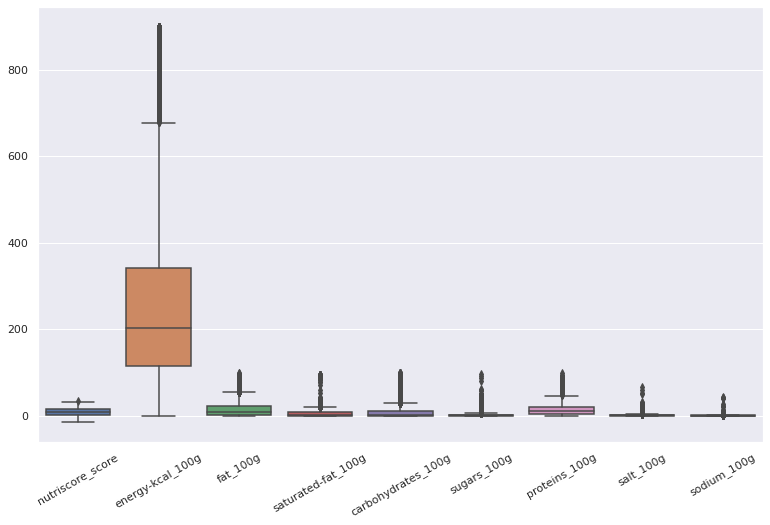

In [175]:
ax = sns.boxplot(data=sm_df[sm_num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

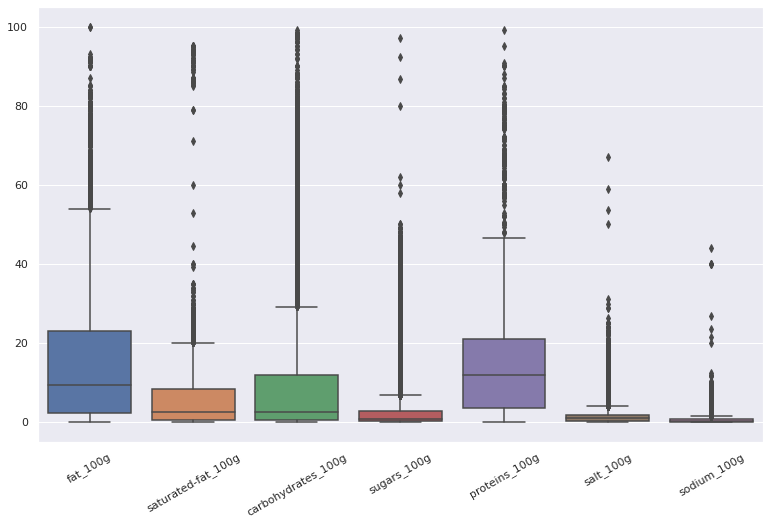

In [176]:
ax = sns.boxplot(data=sm_df[num_100_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


[Text(0, 0, 'energy-kcal_100g')]

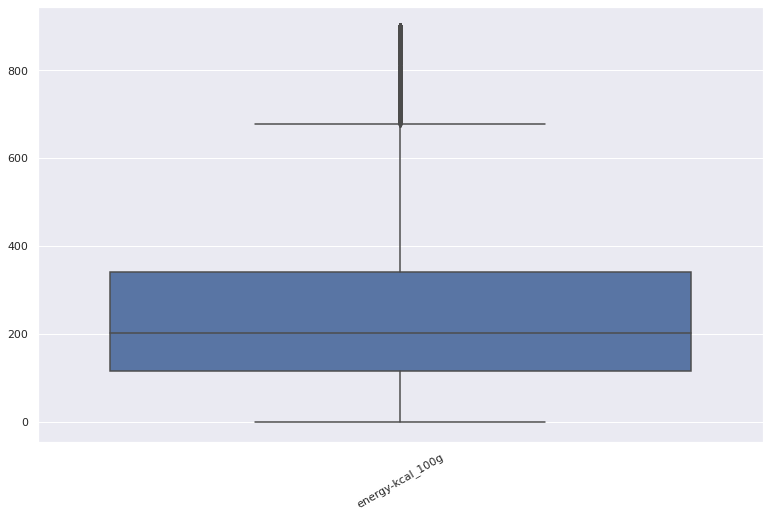

In [177]:
ax = sns.boxplot(data=sm_df[num_kcal_col])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

                               columns  count  null_percent
pnns_groups_1            pnns_groups_1   3642          10.2
energy-kcal_100g      energy-kcal_100g    761           2.1
fat_100g                      fat_100g    620           1.7
carbohydrates_100g  carbohydrates_100g     99           0.3
sugars_100g                sugars_100g     92           0.3
saturated-fat_100g  saturated-fat_100g     63           0.2
proteins_100g            proteins_100g     57           0.2
salt_100g                    salt_100g     68           0.2
sodium_100g                sodium_100g     63           0.2
code                              code      0           0.0
product_name              product_name      0           0.0
nutriscore_score      nutriscore_score      0           0.0
nutriscore_grade      nutriscore_grade      0           0.0


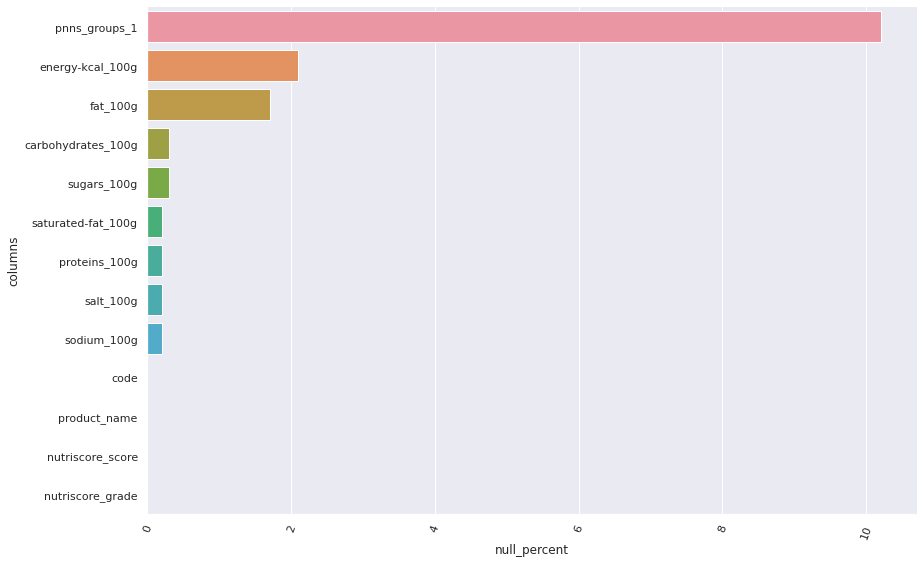

In [178]:
show_nulls(sm_df)

# export to csv

In [179]:
#sm_df.reset_index()

#sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
#print('export finished !')

In [180]:

#sm_df.reset_index()

sm_df.to_csv(path + 'to_input_openfoodfacts.csv', index=False)
print('export finished !')

export finished !


In [181]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août   2022 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 3,5M 12 avril 08:50 clean_openfoodfacts_3.csv
-rw-r--r-- 1 mijka mijka 166M  3 août   2022 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 3,5M 31 mars  11:50 clean_openfoodfacts_x.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril  2022 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril  2022 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv
-rw-r--r-- 1 mijka mijka 3,5M 10 mai   11:55 to_input_openfoodfacts.csv


In [ ]:
sm_df['pnns_groups_1'].unique()

# Imputing

In [ ]:
# => moving importing to a different notebook to reduce memory usage of the whole process.

In [ ]:
all_cols = sm_df.columns
all_cols


In [ ]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [ ]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats


In [ ]:
all_cols

In [ ]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

In [ ]:
#groupby pnns_groups_1, mean, remplir avec mean / categorie
#list1 = ["fat_100g", "salt_100g"]
main_cats

In [ ]:
sm_df.filter(main_cats).head()

In [ ]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")